# **11. Modelo Final: D-DCRNN (Dynamic Diffusion Convolutional RNN)**

Extensión del DCRNN baseline con:
- **Grafo dinámico** aprendido por atención (no estático)
- **Multi-layer DCRNN** con residual connections
- **Predicciones por departamento** con intervalos de confianza
- **Métricas por departamento** (RMSE, MAE, R²)
- Misma estructura de pipeline que el DCRNN baseline

## **11.1. Librerías**

Se importan las librerías requeridas para la implementación del modelo final, incluyendo aquellas necesarias para el procesamiento de datos, el entrenamiento del modelo, la evaluación de desempeño y la visualización de resultados.

In [2]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

## **11.2. Configuración Reproducibilidad**

In [3]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


Se verifica la configuración del entorno de ejecución y del dispositivo de cómputo a utilizar, incluyendo la disponibilidad de aceleración por GPU (CUDA), así como las versiones de las principales librerías empleadas (Python, PyTorch, NumPy y Pandas). Esta verificación garantiza la reproducibilidad del experimento y la correcta ejecución del modelo en un entorno computacional adecuado.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

Se define una función de fijación de semilla para garantizar la reproducibilidad de los experimentos, asegurando la consistencia en la generación de números aleatorios en CPU y GPU, así como en las operaciones de PyTorch y NumPy. Adicionalmente, se configura la semilla en los procesos de carga de datos y se habilitan opciones de determinismo en cuDNN para asegurar resultados consistentes entre ejecuciones.

## **11.3. Carga de Datos & Preprocesamiento**

### **11.3.1. Carga de Datos**

Se carga la base de datos desde un archivo CSV y se realiza la conversión de la variable de fecha al formato `datetime` para su correcto tratamiento temporal. Posteriormente, los datos se ordenan por departamento y fecha de inicio, garantizando la coherencia de la estructura temporal antes del análisis, y se verifica la dimensión del conjunto de datos.

In [5]:
df = pd.read_csv("Bases_Datos/df_full.csv")

df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


### **11.3.2. Feature Engineering**

Se generan variables cíclicas para representar la estacionalidad semanal, capturando adecuadamente la naturaleza periódica de la serie temporal. Asimismo, se define el conjunto de variables predictoras de manera consistente con el baseline DCRNN, asegurando comparabilidad entre modelos bajo un mismo espacio de características.

In [6]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")
df["week_norm"] = df["semana"] / weeks_per_year
df["week_sin"]  = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]  = np.cos(2 * np.pi * df["week_norm"])

In [ ]:


FEATURES = [
    "inc_lag_1",  "inc_lag_2",  "inc_lag_3",  "inc_lag_4",
    "inc_lag_8",  "inc_lag_12", "inc_lag_20",

    "temp_lag_1",    "temp_lag_2",    "temp_lag_4",
    "temp_lag_8",    "temp_lag_12",   "temp_lag_20",

    "humedad_lag_1", "humedad_lag_2", "humedad_lag_4",
    "humedad_lag_8", "humedad_lag_12","humedad_lag_20",

    "precip_lag_1",  "precip_lag_2",  "precip_lag_4",
    "precip_lag_8",  "precip_lag_12", "precip_lag_20",

    "poblacion",
    "prop_rural",
    "week_sin",
    "week_cos"
]

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"

print(f"Features: {len(FEATURES)} | Target: {TARGET}")

Features: 29 | Target: incidencia_log


### **11.3.3. Grafo Espacial**

Se construye la matriz de adyacencia tipo Queen de orden estático, la cual se utiliza como estructura de referencia espacial (prior) para la modelación del grafo dinámico en la arquitectura D-DCRNN. Esta matriz permite incorporar la dependencia geoespacial entre unidades territoriales dentro del proceso de aprendizaje.

In [7]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)

gdf = gpd.read_file(
    "Covariables/MGN_ADM_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO_limpio.shp"
)
gdf = gdf.set_index("dpto_cnmbr").loc[departments].reset_index()


def build_queen_adj(gdf, departments):
    w   = Queen.from_dataframe(gdf)
    adj = np.zeros((len(departments), len(departments)), dtype=np.float32)
    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            adj[i, j] = 1.0
    np.fill_diagonal(adj, 1.0)
    return adj


def normalize_adj(adj):
    D = np.diag(np.power(adj.sum(axis=1), -0.5))
    return (D @ adj @ D).astype(np.float32)


adj_raw        = build_queen_adj(gdf, departments)
adj_normalized = normalize_adj(adj_raw)

adj_matrix = torch.tensor(
    adj_normalized, dtype=torch.float32
).to(DEVICE)

print(f"NUM_NODES: {NUM_NODES}")
print(f"Adj matrix shape: {adj_matrix.shape}")

/tmp/ipykernel_162484/367803614.py:13: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w   = Queen.from_dataframe(gdf)


NUM_NODES: 32
Adj matrix shape: torch.Size([32, 32])


## **11.4. Validación Temporal Anidada (Nested time-series cross-validation)**

Este esquema implementa una validación cruzada temporal anidada, donde los outer folds evalúan la capacidad de generalización del modelo en años futuros, mientras que los inner folds permiten la optimización de hiperparámetros sin contaminación del conjunto de prueba. Este esquema se adopta para garantizar una evaluación realista, libre de fuga de información y comparable entre modelos, asegurando que todos sean evaluados bajo las mismas condiciones temporales y simulando el escenario real de predicción en el que solo se dispone de información pasada.

In [8]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds       = []
    outer_years = [2022, 2023, 2024]
    for test_year in outer_years:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()
        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()
        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })
    return inner_folds


outer_folds = create_outer_folds(df)

## **11.5. Construcción de Secuencias Temporales Supervisadas y su Normalización**

### **11.5.1. Sliding Windows**

Se reorganiza el dataset en formato supervisado mediante una estrategia de ventanas deslizantes (sliding windows). Para cada variable explicativa, los datos se pivotan por fecha y departamento, generando tensores espacio-temporales. A partir de esto, se construyen pares entrada–salida donde X representa una secuencia de longitud window_size y y el horizonte de predicción horizon, permitiendo modelar dependencias temporales y espaciales de forma simultánea

In [11]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(base_dates)
    )

### **11.5.2. Scale Data**

Se aplica una transformación robusta mediante RobustScaler, ajustada únicamente sobre el conjunto de entrenamiento para evitar data leakage. La normalización se realiza sobre la dimensión de características, garantizando estabilidad numérica del modelo y mejorando la convergencia durante el entrenamiento.

In [12]:
def scale_data(X_train, X_val):
    scaler       = RobustScaler()
    _, _, _, n_f = X_train.shape
    X_train_2d   = X_train.reshape(-1, n_f)
    scaler.fit(X_train_2d)
    X_train_sc   = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc     = scaler.transform(X_val.reshape(-1, n_f)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **11.6. Utilidades de Entrenamiento**

### **11.6.1. Early Stopping**

Igual que en los modelos anteriores, se implementa un mecanismo de *early stopping* que detiene el entrenamiento cuando la pérdida en validación no presenta mejoras durante un número determinado de épocas (*patience*), con el objetivo de evitar el sobreajuste y conservar la mejor configuración del modelo obtenida durante el proceso de entrenamiento.

In [10]:
class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


### **11.6.2. Ciclo de Entrenamiento**

Se define el procedimiento de entrenamiento por época, donde el modelo se ejecuta en modo training, se calculan las predicciones y la pérdida respecto a los valores reales, y se actualizan los parámetros mediante backpropagation. Además, se aplica gradient clipping para estabilizar el entrenamiento y evitar explosión de gradientes.

In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred, _ = model(X_batch, adj_matrix)   # D-DCRNN devuelve (pred, dyn_adj)
        loss     = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

### **11.6.3. Validación**

Se evalúa el modelo sin actualización de gradientes, calculando la pérdida promedio en el conjunto de validación. Este valor se utiliza como criterio principal para el early stopping y para el seguimiento del rendimiento del modelo durante el entrenamiento.

In [ ]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred, _ = model(X_batch, adj_matrix)
            loss     = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **11.7. Arquitectura D-DCRNN**

### Mejoras sobre el baseline DCRNN:
1. **Graph Attention Module** — genera un grafo dinámico aprendido a partir de los embeddings de nodo. Se combina con el grafo estático Queen (prior espacial).
2. **Multi-layer DCRNNCell** — apilado de celdas con residual connection para mayor capacidad expresiva.
3. **Layer Normalization** — estabiliza el entrenamiento y acelera la convergencia.
4. **Output head con dropout** — regularización antes de la proyección final.

### **11.7.1. Definición Conjunto de Datos**

Se define un conjunto de datos personalizado mediante la clase `Dataset`, el cual permite estructurar las entradas y salidas en formato tensorial compatible con PyTorch. Esta implementación facilita el manejo eficiente de las secuencias temporales durante el entrenamiento del modelo, asegurando su correcta indexación y acceso en el proceso de Carga de datos.


In [ ]:
class Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### **11.7.2. Grafico Dinámico**

Se define *DynamicGraphLearner*, el cual aprende de una representación latente de cada nodo mediante embeddings entrenables. A partir de estos embeddings se construye una matriz de adyacencia dinámica, la cual captura relaciones espaciales no estáticas entre unidades geográficas. Esta matriz se normaliza por filas para garantizar estabilidad numérica y posteriormente se combina con un grafo estático tipo Queen como prior estructural.

In [14]:
class DynamicGraphLearner(nn.Module):

    def __init__(self, num_nodes, embed_dim=16):
        super().__init__()
        
        self.node_emb = nn.Embedding(num_nodes, embed_dim)
        self.W1 = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W2 = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self):
        idx  = torch.arange(self.node_emb.num_embeddings,
                            device=self.node_emb.weight.device)
        E    = self.node_emb(idx)               
        A    = torch.tanh(self.W1(E)) @ torch.tanh(self.W2(E)).T   
        A    = F.relu(A)                        
        
        D    = A.sum(dim=-1, keepdim=True).clamp(min=1e-6)
        A    = A / D
        return A                               

### **11.7.3. Convolución por Difusión**

Se implementa una operación de difusión sobre grafos que integra simultáneamente la estructura estática y la dinámica mediante una combinación convexa controlada por el parámetro α. La propagación de información se realiza sobre múltiples soportes (identidad, matriz de adyacencia y su transpuesta), permitiendo capturar dependencias espaciales locales y bidireccionales.

In [ ]:
def diff_conv_combined(x, adj_static, adj_dynamic, alpha=0.5, K=2):
    A_comb  = (1 - alpha) * adj_static + alpha * adj_dynamic
    nodes   = x.shape[1]
    supports = [
        torch.eye(nodes, device=x.device),
        A_comb,
        A_comb.T
    ]
    out = []
    for support in supports:
        x0   = x
        out_k = x0
        for _ in range(1, K + 1):
            x0    = torch.einsum("ij,bjf->bif", support, x0)
            out_k = out_k + x0
        out.append(out_k)
    return torch.cat(out, dim=-1)   # (batch, nodes, features * 3)




### **11.7.4. Celda D-DCRNN**

Se define una celda recurrente basada en GRU que incorpora convolución en grafos mediante difusión. El estado oculto se actualiza utilizando compuertas de actualización y reinicio, mientras que la información espacial se integra a través de la convolución sobre el grafo combinado. Además, se aplica normalización por capas para estabilizar el entrenamiento.

In [ ]:
class DDCRNNCell(nn.Module):

    def __init__(self, in_dim, hidden_dim, K=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.K          = K
        gc_out_dim      = in_dim * 3          # 3 soportes

        self.gate = nn.Linear(gc_out_dim + hidden_dim, 2 * hidden_dim)
        self.cand = nn.Linear(gc_out_dim + hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)  # estabiliza entrenamiento

    def forward(self, x, h, adj_static, adj_dynamic, alpha):
        x_gc     = diff_conv_combined(x, adj_static, adj_dynamic, alpha, self.K)
        combined = torch.cat([x_gc, h], dim=-1)
        z, r     = torch.sigmoid(self.gate(combined)).chunk(2, dim=-1)
        h_tilde  = torch.tanh(self.cand(torch.cat([x_gc, r * h], dim=-1)))
        h_new    = self.norm((1 - z) * h + z * h_tilde)
        return h_new


### **11.7.5. Estructura Modelo Completo**

Finalmente, se define la clase **DDCRNN**, correspondiente al modelo propuesto. Esta arquitectura apila múltiples celdas D-DCRNN con el objetivo de capturar dependencias espaciotemporales de mayor complejidad. En cada instante temporal, el estado oculto se actualiza integrando información proveniente tanto del grafo dinámico aprendido como del grafo estático utilizado como *prior* estructural. Finalmente, una capa completamente conectada (*fully connected*) proyecta el estado oculto hacia el horizonte de predicción, generando las salidas del modelo.


In [15]:
class DDCRNN(nn.Module):
    
    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_dim,
        horizon,
        num_layers=2,
        K=2,
        embed_dim=16,
        alpha=0.5,
        dropout=0.1
    ):
        super().__init__()
        self.horizon    = horizon
        self.num_nodes  = num_nodes
        self.num_layers = num_layers
        self.alpha      = alpha

        self.graph_learner = DynamicGraphLearner(num_nodes, embed_dim)

        self.cells = nn.ModuleList()
        for layer in range(num_layers):
            in_d = in_channels if layer == 0 else hidden_dim
            self.cells.append(DDCRNNCell(in_d, hidden_dim, K))

        self.res_proj = (
            nn.Linear(in_channels, hidden_dim)
            if in_channels != hidden_dim else None
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, horizon)

    def forward(self, x, adj_static):

        batch, T, N, F = x.shape

        adj_dyn = self.graph_learner()

        hs = [
            torch.zeros(batch, N, self.cells[0].hidden_dim, device=x.device)
            for _ in range(self.num_layers)
        ]

        for t in range(T):
            x_t = x[:, t]                      
            for layer_idx, cell in enumerate(self.cells):
                h_in  = hs[layer_idx]
                h_out = cell(x_t, h_in, adj_static, adj_dyn, self.alpha)
                if layer_idx > 0:
                    h_out = h_out + h_in
                hs[layer_idx] = h_out
                x_t = h_out                    

        h_last = self.dropout(hs[-1])          
        out    = self.fc(h_last)               
        out    = out.permute(0, 2, 1)          

        return out, adj_dyn

## **11.8. Optimización de Hiperparámetros (Optuna)**

Se conserva el espacio de hiperparámetros definido en el modelo baseline, incorporando además parámetros específicos de la arquitectura D-DCRNN. Entre estos se incluyen embed_dim, que controla la dimensionalidad de los embeddings utilizados en el aprendizaje del grafo dinámico; alpha, que regula la contribución relativa entre el grafo dinámico y el grafo estático; y num_layers, que determina la profundidad de la red mediante el apilamiento de múltiples celdas DCRNN.

### **11.8.1. Estructuras Globales & Delimitación Conjunto de Datos**

Se definen estructuras globales para el almacenamiento de resultados asociados al proceso de entrenamiento, validación y optimización de hiperparámetros, incluyendo métricas por *trial*, *folds*, residuales, tiempos de inferencia, parámetros óptimos, predicciones y pérdidas. Adicionalmente, se delimita el conjunto de datos destinado a la fase de *tuning* utilizando únicamente información previa a 2022, y se construyen los *inner folds* correspondientes para los años de validación 2019, 2020 y 2021, asegurando una optimización libre de fuga de información temporal.

In [ ]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS  = []
ALL_RESIDUALS     = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS   = []
ALL_RESULTS       = []
ALL_PREDICTIONS   = []
ALL_LOSSES        = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)

### **11.8.2. Función Objetivo Optuna**

Se define la función objetivo para la optimización de hiperparámetros mediante Optuna, en la cual se evalúa el desempeño del modelo DDCRNN sobre validación cruzada temporal en los *inner folds*. Se exploran tanto hiperparámetros generales del modelo como parámetros específicos de la arquitectura propuesta. La métrica de optimización es el RMSE promedio entre folds, incorporando *early stopping* para evitar sobreajuste. Los resultados de cada *trial* y fold se almacenan para su posterior análisis.

In [ ]:
def objective(trial):

    window_size   = trial.suggest_categorical("window_size",   [4, 8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    hidden_size   = trial.suggest_categorical("hidden_size",   [32, 64, 128])
    num_layers    = trial.suggest_int(        "num_layers",    1, 3)
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.4, step=0.1)
    K             = trial.suggest_int(        "K",             1, 3)
    embed_dim     = trial.suggest_categorical("embed_dim",     [8, 16, 32])
    alpha         = trial.suggest_float(      "alpha",         0.1, 0.9, step=0.1)

    rmse_folds  = []
    fold_errors = []

    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _ = create_windows(
            fold["inner_train"], FEATURES, TARGET, window_size, 4
        )
        X_val,   y_val,   _ = create_windows(
            fold["inner_val"],   FEATURES, TARGET, window_size, 4
        )

        X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)

        train_dataset = Dataset(X_train_sc, y_train)
        val_dataset   = Dataset(X_val_sc,   y_val)

        g.manual_seed(seed)
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=False,
            worker_init_fn=seed_worker, generator=g
        )
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, shuffle=False
        )

        model = DDCRNN(
            num_nodes   = NUM_NODES,
            in_channels = len(FEATURES),
            hidden_dim  = hidden_size,
            horizon     = 4,
            num_layers  = num_layers,
            K           = K,
            embed_dim   = embed_dim,
            alpha       = alpha,
            dropout     = dropout
        ).to(DEVICE)

        criterion      = nn.MSELoss()
        optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):
            train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_loss = validate_one_epoch(model, val_loader, criterion, DEVICE)
            
            early_stopping.step(val_loss)
            if early_stopping.stop:
                break
            

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred, _ = model(X_batch.to(DEVICE), adj_matrix)
                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds  = np.concatenate(preds)
        trues  = np.concatenate(trues)
        errors = trues - preds
        rmse   = np.sqrt(mean_squared_error(trues.flatten(), preds.flatten()))

        rmse_folds.append(rmse)
        fold_errors.append({
            "trial": trial.number, "seed": seed, "fold": fold_id,
            "rmse": rmse,
            "error_mean": float(np.mean(errors)),
            "error_std":  float(np.std(errors))
        })

    rmse_mean = float(np.mean(rmse_folds))
    rmse_std  = float(np.std(rmse_folds))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size":  batch_size,  "hidden_size":   hidden_size,
        "num_layers":  num_layers,  "dropout":       dropout,
        "K": K, "embed_dim": embed_dim, "alpha": alpha,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })
    ALL_OPTUNA_FOLDS.extend(fold_errors)

    trial.set_user_attr("rmse_folds", rmse_folds)
    trial.set_user_attr("rmse_std",   rmse_std)

    return rmse_mean

## **11.9. Pipeline Principal — Train, Validation & Test**

Para cada semilla, se realiza un proceso secuencial que incluye la optimización de hiperparámetros mediante Optuna, el entrenamiento del modelo utilizando los *outer folds* y, finalmente, la evaluación del desempeño en el conjunto de prueba.

In [ ]:
for seed in SEEDS:

    print("\n" + "="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params
    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"Modelos/DDCRNN/ddcrnn_best_params_seed_{seed}.csv",
        index=False
    )
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n" + "="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]
        K             = best_params["K"]
        embed_dim     = best_params["embed_dim"]
        alpha         = best_params["alpha"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]


        X_train, y_train, train_dates = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )
        X_val,   y_val,   val_dates   = create_windows(
            final_val_df,   FEATURES, TARGET, window_size, 4
        )
        X_test,  y_test,  test_dates  = create_windows(
            final_test_df,  FEATURES, TARGET, window_size, 4
        )

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)


        train_loader = DataLoader(
            Dataset(X_train_sc, y_train),
            batch_size=batch_size, shuffle=False
        )
        val_loader = DataLoader(
            Dataset(X_val_sc, y_val),
            batch_size=batch_size, shuffle=False
        )
        test_loader = DataLoader(
            Dataset(X_test_sc, y_test),
            batch_size=batch_size, shuffle=False
        )

        model = DDCRNN(
            num_nodes   = NUM_NODES,
            in_channels = len(FEATURES),
            hidden_dim  = hidden_size,
            horizon     = 4,
            num_layers  = num_layers,
            K           = K,
            embed_dim   = embed_dim,
            alpha       = alpha,
            dropout     = dropout
        ).to(DEVICE)

        criterion  = nn.MSELoss()
        optimizer  = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )
        early_stopping = EarlyStopping(patience=20)
        best_model, best_loss = None, np.inf
        total_train_time = 0.0

        for epoch in range(300):
            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )
            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )
            scheduler.step(val_loss)

            epoch_time        = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1:3d}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss":   val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss  = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)
            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"Modelos/DDCRNN/ddcrnn_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()
        start_inference = time.time()
        predictions, targets = [], []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred, _ = model(X_batch.to(DEVICE), adj_matrix)
                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference
        predictions    = np.concatenate(predictions)
        targets        = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse, "rmse": rmse, "mae": mae, "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })

        rows = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    y_true   = targets[i, h, node]
                    y_pred   = predictions[i, h, node]
                    residual = y_true - y_pred
                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year":  outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base":   test_dates[i],
                        "horizonte":    h + 1,
                        "y_true_log":   y_true,
                        "y_pred_log":   y_pred,
                        "y_true_real":  np.expm1(y_true),
                        "y_pred_real":  np.expm1(y_pred),
                        "residual":     residual,
                        "abs_error":    abs(residual),
                        "sq_error":     residual ** 2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base":   test_dates[i],
                        "horizonte":    h + 1,
                        "residual":     residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))


SEED 42


[I 2026-06-02 10:45:42,753] A new study created in memory with name: no-name-925976a5-3d84-4f58-9fb9-24766f3a9be1


Seed fijada: 42


[I 2026-06-02 10:47:24,999] Trial 0 finished with value: 0.4377308290562633 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.4, 'K': 3, 'embed_dim': 8, 'alpha': 0.30000000000000004}. Best is trial 0 with value: 0.4377308290562633.
[I 2026-06-02 10:49:24,738] Trial 1 finished with value: 0.5932463596344097 and parameters: {'window_size': 16, 'learning_rate': 0.00019010245319870352, 'batch_size': 32, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'K': 1, 'embed_dim': 8, 'alpha': 0.9}. Best is trial 0 with value: 0.4377308290562633.
[I 2026-06-02 10:49:42,038] Trial 2 finished with value: 0.5393367124226651 and parameters: {'window_size': 4, 'learning_rate': 0.0023359635026261607, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.30000000000000004, 'K': 1, 'embed_dim': 16, 'alpha': 0.9}. Best is trial 0 with value: 0.4377308290562633.
[I 2026-06-02 10:50:03,448] Trial 3 fini


Mejores hiperparámetros para seed 42:
{'window_size': 8, 'learning_rate': 0.0002147388578723174, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.4, 'K': 3, 'embed_dim': 32, 'alpha': 0.30000000000000004}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 0.9548 | Val 0.2395 | Time 0.84s
Epoch   2 | Train 0.4669 | Val 0.1829 | Time 0.82s
Epoch   3 | Train 0.3701 | Val 0.1461 | Time 0.85s
Epoch   4 | Train 0.3219 | Val 0.1436 | Time 0.84s
Epoch   5 | Train 0.2834 | Val 0.1330 | Time 0.90s
Epoch   6 | Train 0.2551 | Val 0.1255 | Time 0.97s
Epoch   7 | Train 0.2355 | Val 0.1243 | Time 0.88s
Epoch   8 | Train 0.2194 | Val 0.1210 | Time 0.86s
Epoch   9 | Train 0.2048 | Val 0.1179 | Time 0.90s
Epoch  10 | Train 0.1943 | Val 0.1153 | Time 1.06s
Epoch  11 | Train 0.1880 | Val 0.1144 | Time 0.88s
Epoch  12 | Train 0.1816 | Val 0.1138 | Time 0.93s
Epoch  13 | Train 0.1767 | Val 0.1125 | Time 1.01s
Epoch  14 | Train 0.1708 | Val 0.1120 | Time 0.90s
Epoch  15 | Train 0.1665 | Val

...


Mejores hiperparámetros para seed 123:
{'window_size': 16, 'learning_rate': 0.00021456426442853065, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.4, 'K': 1, 'embed_dim': 32, 'alpha': 0.7000000000000001}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 1.1094 | Val 0.4532 | Time 0.92s
Epoch   2 | Train 0.5663 | Val 0.2395 | Time 0.93s
Epoch   3 | Train 0.4285 | Val 0.2045 | Time 0.91s
Epoch   4 | Train 0.3696 | Val 0.1859 | Time 0.88s
Epoch   5 | Train 0.3199 | Val 0.1712 | Time 0.87s
Epoch   6 | Train 0.2934 | Val 0.1627 | Time 0.95s
Epoch   7 | Train 0.2696 | Val 0.1553 | Time 0.95s
Epoch   8 | Train 0.2501 | Val 0.1491 | Time 0.94s
Epoch   9 | Train 0.2347 | Val 0.1445 | Time 0.95s
Epoch  10 | Train 0.2234 | Val 0.1413 | Time 0.96s
Epoch  11 | Train 0.2131 | Val 0.1380 | Time 0.91s
Epoch  12 | Train 0.2045 | Val 0.1358 | Time 0.87s
Epoch  13 | Train 0.1968 | Val 0.1339 | Time 0.88s
Epoch  14 | Train 0.1894 | Val 0.1333 | Time 0.88s
Epoch  15 | Train 0.1870 | Va

[I 2026-06-02 12:21:46,500] A new study created in memory with name: no-name-2942e601-1f98-4323-9de3-44a9e5df387b


Epoch  65 | Train 0.1202 | Val 0.1601 | Time 1.05s

SEED 2024
Seed fijada: 2024


[I 2026-06-02 12:22:30,365] Trial 0 finished with value: 0.4331634611411544 and parameters: {'window_size': 8, 'learning_rate': 0.00025706201341357387, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.30000000000000004, 'K': 2, 'embed_dim': 8, 'alpha': 0.5}. Best is trial 0 with value: 0.4331634611411544.
[I 2026-06-02 12:26:15,615] Trial 1 finished with value: 0.6144682790971948 and parameters: {'window_size': 12, 'learning_rate': 0.00015526883974271638, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'K': 2, 'embed_dim': 16, 'alpha': 0.4}. Best is trial 0 with value: 0.4331634611411544.
[I 2026-06-02 12:27:00,257] Trial 2 finished with value: 0.5517439962973074 and parameters: {'window_size': 4, 'learning_rate': 0.0006848110664589038, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.1, 'K': 2, 'embed_dim': 8, 'alpha': 0.1}. Best is trial 0 with value: 0.4331634611411544.
[I 2026-06-02 12:29:14,553] Trial 3 finished with valu


Mejores hiperparámetros para seed 2024:
{'window_size': 12, 'learning_rate': 0.00044156485797434026, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.4, 'K': 1, 'embed_dim': 32, 'alpha': 0.8}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 0.8008 | Val 0.1957 | Time 0.70s
Epoch   2 | Train 0.3702 | Val 0.1754 | Time 0.71s
Epoch   3 | Train 0.2914 | Val 0.1572 | Time 0.72s
Epoch   4 | Train 0.2474 | Val 0.1437 | Time 0.74s
Epoch   5 | Train 0.2239 | Val 0.1354 | Time 0.71s
Epoch   6 | Train 0.2076 | Val 0.1302 | Time 0.72s
Epoch   7 | Train 0.1949 | Val 0.1281 | Time 0.73s
Epoch   8 | Train 0.1837 | Val 0.1260 | Time 0.72s
Epoch   9 | Train 0.1795 | Val 0.1245 | Time 0.71s
Epoch  10 | Train 0.1746 | Val 0.1235 | Time 0.71s
Epoch  11 | Train 0.1716 | Val 0.1230 | Time 0.72s
Epoch  12 | Train 0.1663 | Val 0.1220 | Time 0.71s
Epoch  13 | Train 0.1629 | Val 0.1210 | Time 0.73s
Epoch  14 | Train 0.1592 | Val 0.1219 | Time 0.72s
Epoch  15 | Train 0.1568 | Val 0.1209 | Tim

## **11.10. Guardado de Resultados**

In [ ]:

results_df       = pd.DataFrame(ALL_RESULTS)
predictions_df   = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df        = pd.DataFrame(ALL_LOSSES)
best_params_df   = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df  = pd.DataFrame(ALL_OPTUNA_FOLDS)
inference_df     = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df     = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "Modelos/DDCRNN"

results_df.to_csv(      f"{BASE_PATH}/ddcrnn_results.csv",           index=False)
predictions_df.to_csv(  f"{BASE_PATH}/ddcrnn_predictions.csv",       index=False)
losses_df.to_csv(       f"{BASE_PATH}/ddcrnn_training_history.csv",  index=False)
best_params_df.to_csv(  f"{BASE_PATH}/ddcrnn_best_params.csv",       index=False)
optuna_trials_df.to_csv(f"{BASE_PATH}/ddcrnn_optuna_trials.csv",     index=False)
optuna_folds_df.to_csv( f"{BASE_PATH}/ddcrnn_optuna_folds.csv",      index=False)
inference_df.to_csv(    f"{BASE_PATH}/ddcrnn_inference_time.csv",     index=False)
residuals_df.to_csv(    f"{BASE_PATH}/ddcrnn_residuals.csv",          index=False)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)
print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.165654  0.405301  0.287039   
std     971.383421    0.866025     0.866025  0.032628  0.039474  0.031032   
min      42.000000    1.000000  2022.000000  0.126965  0.356322  0.250304   
25%      42.000000    1.000000  2022.000000  0.142265  0.377180  0.268863   
50%     123.000000    2.000000  2023.000000  0.153872  0.392265  0.270987   
75%    2024.000000    3.000000  2024.000000  0.205260  0.453056  0.322798   
max    2024.000000    3.000000  2024.000000  0.209298  0.457491  0.334409   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean   0.763429   48.341115        0.030151  
std    0.026186   10.205956        0.003484  
min    0.718401   31.421836        0.023167  
25%    0.738623   44.261640        0.029301  
50%    0.771979

## **11.11. Evaluación del Modelo**

### **11.11.1. Métricas Globales**

In [ ]:
BASE_PATH    = "Modelos/DDCRNN"
results      = pd.read_csv(f"{BASE_PATH}/ddcrnn_results.csv")
preds        = pd.read_csv(f"{BASE_PATH}/ddcrnn_predictions.csv")
residuals    = pd.read_csv(f"{BASE_PATH}/ddcrnn_residuals.csv")
history      = pd.read_csv(f"{BASE_PATH}/ddcrnn_training_history.csv")

In [ ]:
def compute_metrics(df, col_true="y_true_real", col_pred="y_pred_real", col_seed="seed"):
    metrics = []
    for seed in df[col_seed].unique():
        s    = df[df[col_seed] == seed]
        rmse = np.sqrt(mean_squared_error(s[col_true], s[col_pred]))
        mae  = mean_absolute_error(s[col_true], s[col_pred])
        r2   = r2_score(s[col_true], s[col_pred])
        metrics.append({"seed": seed, "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds, "y_true_real", "y_pred_real")
metrics_log  = compute_metrics(preds, "y_true_log",  "y_pred_log")

print("Métricas en escala real:")
print(metrics_real)
print("\nMétricas en escala log:")
print(metrics_log)

metrics_real.to_csv(f"{BASE_PATH}/metrics_ddcrnn.csv",     index=False)
metrics_log.to_csv( f"{BASE_PATH}/metrics_ddcrnn_log.csv", index=False)

Métricas en escala real:
   seed      RMSE       MAE        R2
0    42  4.709310  2.205095  0.654592
1   123  4.124765  2.080236  0.679156
2  2024  4.554427  2.228869  0.653683

Métricas en escala log:
   seed      RMSE       MAE        R2
0    42  0.403859  0.283470  0.811572
1   123  0.407338  0.285521  0.797765
2  2024  0.408394  0.291029  0.803635


Los resultados muestran un desempeño consistente del modelo a través de diferentes semillas, con un RMSE promedio en escala real de aproximadamente 4.46, MAE de 2.17 y un R² de 0.662, lo que indica una capacidad explicativa moderada y errores absolutos no despreciables en la predicción de la incidencia. En términos de estabilidad, las variaciones entre semillas son relativamente bajas, lo que sugiere un comportamiento robusto frente a la inicialización del modelo. En escala logarítmica, el desempeño mejora notablemente, alcanzando un R² promedio cercano a 0.80, junto con errores reducidos (RMSE ≈ 0.406 y MAE ≈ 0.286), lo que evidencia una mejor capacidad del modelo para capturar la estructura relativa y las dinámicas de crecimiento o disminución de la serie temporal. En conjunto, estos resultados indican que el modelo es más eficaz para representar patrones estructurales de la incidencia que para producir predicciones absolutas altamente precisas en la escala original.

In [ ]:
summary_real = metrics_real[["RMSE","MAE","R2"]].agg(["mean","std"])
summary_log  = metrics_log[["RMSE","MAE","R2"]].agg(["mean","std"])

print("\nResumen en escala real:\n", summary_real)
print("\nResumen en escala log:\n",  summary_log)


Resumen en escala real:
           RMSE      MAE        R2
mean  4.462834  2.17140  0.662477
std   0.302845  0.07984  0.014451

Resumen en escala log:
           RMSE       MAE        R2
mean  0.406530  0.286674  0.804324
std   0.002373  0.003909  0.006929


En escala real, el modelo presenta un RMSE medio de 4.46, MAE de 2.17 y un R² de 0.662, con una variabilidad moderada entre ejecuciones (RMSE std = 0.30), lo que indica un desempeño aceptable pero con margen de error en la predicción absoluta de la incidencia. En contraste, en escala logarítmica se observa un mejor ajuste global, con un RMSE de 0.406, MAE de 0.287 y un R² de 0.804, además de una baja variabilidad (RMSE std = 0.002), lo que evidencia una alta estabilidad y una mejor capacidad del modelo para capturar la dinámica relativa de la serie temporal.

### **11.11.2. Métricas por Departamento con Intervalos de Confianza**

In [ ]:
def compute_metrics_by_dept(
    df,
    col_true   = "y_true_real",
    col_pred   = "y_pred_real",
    col_dept   = "departamento",
    col_seed   = "seed",
    confidence = 0.95
):
    records = []
    alpha   = 1 - confidence

    for dept in df[col_dept].unique():
        dept_df = df[df[col_dept] == dept]

        rmse_per_seed, mae_per_seed, r2_per_seed = [], [], []

        for seed in dept_df[col_seed].unique():
            s    = dept_df[dept_df[col_seed] == seed]
            if len(s) < 2:
                continue
            rmse_per_seed.append(
                np.sqrt(mean_squared_error(s[col_true], s[col_pred]))
            )
            mae_per_seed.append(
                mean_absolute_error(s[col_true], s[col_pred])
            )
            r2_per_seed.append(
                r2_score(s[col_true], s[col_pred])
            )

        def ci(series):
            if len(series) < 2:
                return np.mean(series), np.nan, np.nan
            m    = np.mean(series)
            sem  = st.sem(series)
            lo, hi = st.t.interval(
                confidence, df=len(series)-1, loc=m, scale=sem
            )
            return m, lo, hi

        rmse_m, rmse_lo, rmse_hi = ci(rmse_per_seed)
        mae_m,  mae_lo,  mae_hi  = ci(mae_per_seed)
        r2_m,   r2_lo,   r2_hi   = ci(r2_per_seed)

        records.append({
            "departamento": dept,
            "RMSE_mean":  rmse_m,  "RMSE_ci_lo": rmse_lo, "RMSE_ci_hi": rmse_hi,
            "MAE_mean":   mae_m,   "MAE_ci_lo":  mae_lo,  "MAE_ci_hi":  mae_hi,
            "R2_mean":    r2_m,    "R2_ci_lo":   r2_lo,   "R2_ci_hi":   r2_hi,
        })

    return pd.DataFrame(records).sort_values("RMSE_mean")


dept_metrics = compute_metrics_by_dept(preds)
dept_metrics.to_csv(f"{BASE_PATH}/ddcrnn_metrics_by_department.csv", index=False)

print("Top 10 departamentos con menor RMSE:")
print(dept_metrics.head(10).to_string(index=False))

Top 10 departamentos con menor RMSE:
      departamento  RMSE_mean  RMSE_ci_lo  RMSE_ci_hi  MAE_mean  MAE_ci_lo  MAE_ci_hi  R2_mean  R2_ci_lo  R2_ci_hi
       Bogota d.c.   0.248370    0.100509    0.396231  0.163537   0.058652   0.268421 0.000000       NaN       NaN
         Antioquia   0.762805   -0.242854    1.768464  0.509646  -0.153185   1.172476 0.846712  0.454371  1.239052
            Boyaca   0.902577    0.708886    1.096268  0.538407   0.411520   0.665294 0.680601  0.559397  0.801804
         Magdalena   1.096781    0.849011    1.344552  0.826105   0.611821   1.040388 0.718079  0.618928  0.817231
      Cundinamarca   1.143707    0.724596    1.562817  0.710708   0.463630   0.957787 0.874440  0.796214  0.952666
            Caldas   1.267206    0.764929    1.769482  0.772864   0.450019   1.095709 0.755703  0.572517  0.938889
Norte De Santander   1.270266    1.109742    1.430790  0.913718   0.874370   0.953067 0.743255  0.708422  0.778089
             Cesar   1.304593    0.911542  

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Estos resultados muestran el desempeño del modelo desagregado por departamento, ordenado según el RMSE medio más bajo, lo que permite identificar las regiones donde el modelo presenta mejor ajuste. Se observa un desempeño particularmente bueno en departamentos como Bogotá D.C., Antioquia, Boyacá y Cundinamarca, donde los valores de RMSE son relativamente bajos y los intervalos de confianza indican consistencia en la estimación, acompañado en general de valores de R² moderados a altos, lo que sugiere una adecuada capacidad explicativa en estas zonas. En contraste, en departamentos como Córdoba y Nariño se evidencia un deterioro en el desempeño, con mayores errores y menor capacidad explicativa, incluyendo incluso valores negativos de R² en algunos intervalos, lo que sugiere dificultades del modelo para capturar adecuadamente la dinámica local en estas regiones. En conjunto, los resultados reflejan una heterogeneidad espacial en el rendimiento del modelo, indicando que su capacidad predictiva no es homogénea a nivel territorial, aunque mantiene un desempeño globalmente consistente en la mayoría de departamentos.

### **11.11.3. Predicciones por Departamento**

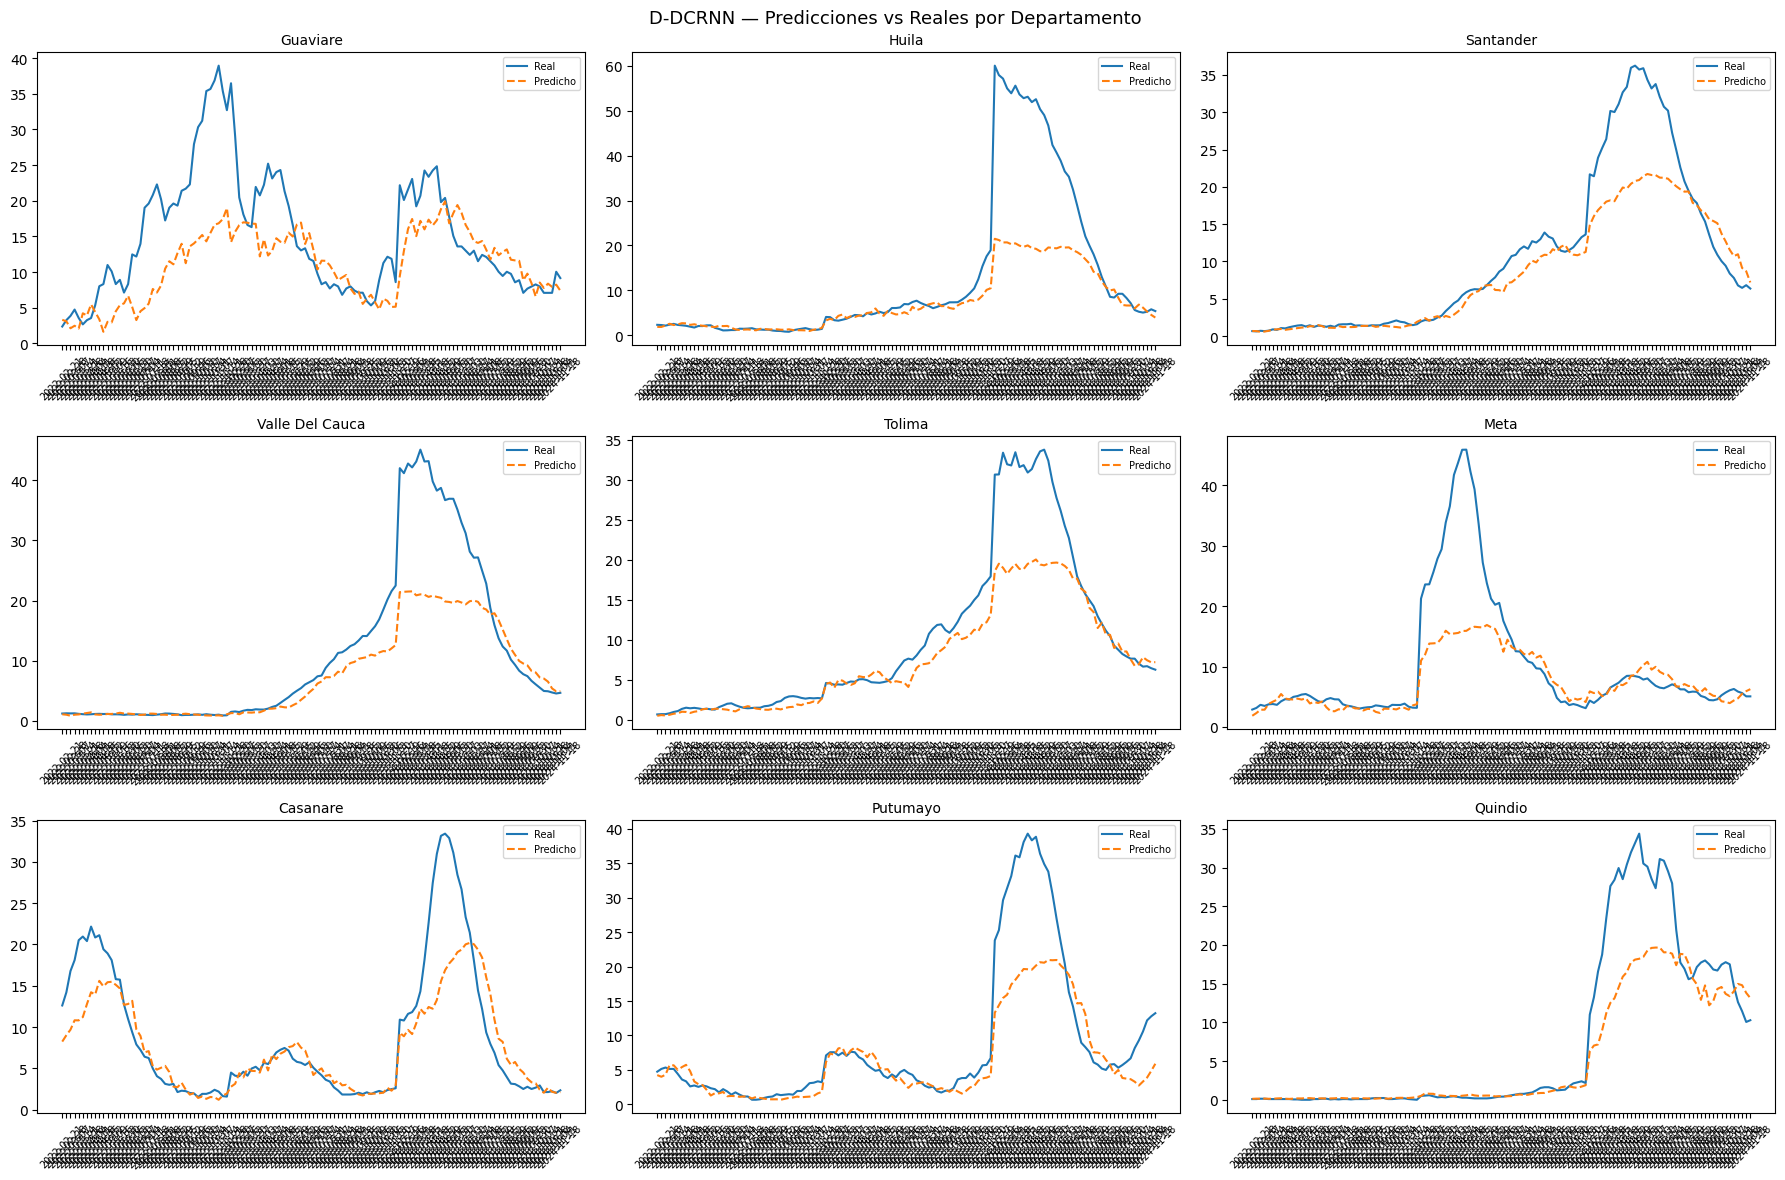

In [ ]:
top_depts = (
    preds.groupby("departamento")["y_true_real"]
    .mean()
    .sort_values(ascending=False)
    .head(9)
    .index.tolist()
)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes      = axes.flatten()

for ax, dept in zip(axes, top_depts):
    sub = preds[preds["departamento"] == dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()

    ax.plot(agg.index, agg["y_true_real"], label="Real",    linewidth=1.5)
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho",linewidth=1.5, linestyle="--")
    ax.set_title(dept, fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("D-DCRNN — Predicciones vs Reales por Departamento", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_predictions_by_dept.png", dpi=150)
plt.show()

El análisis del desempeño predictivo de la arquitectura D-DCRNN evidencia una notable capacidad para modelar la componente temporal y la estacionalidad de las curvas de incidencia en las entidades territoriales evaluadas, manifestando una sincronización precisa en la detección del inicio y declive de las fases de transmisión activa, así como un ajuste riguroso en los periodos de comportamiento basal. Sin embargo, se constata una deficiencia estructural sistemática caracterizada por una severa subestimación en la magnitud de los picos máximos, donde el modelo exhibe un marcado efecto de suavizado y una restricción en la varianza que le impide proyectar los valores extremos de los brotes.

### **11.11.4. Intervalos de Confianza Globales**

In [ ]:
def mean_ci(series, confidence=0.95):
    mean = np.mean(series)
    sem  = st.sem(series)
    ci   = st.t.interval(confidence, df=len(series)-1, loc=mean, scale=sem)
    return mean, ci


rmse_mean, rmse_ci = mean_ci(metrics_real["RMSE"])
mae_mean,  mae_ci  = mean_ci(metrics_real["MAE"])
r2_mean,   r2_ci   = mean_ci(metrics_real["R2"])

print(f"RMSE: {rmse_mean:.4f}  IC 95%: [{rmse_ci[0]:.4f}, {rmse_ci[1]:.4f}]")
print(f"MAE:  {mae_mean:.4f}  IC 95%: [{mae_ci[0]:.4f},  {mae_ci[1]:.4f}]")
print(f"R²:   {r2_mean:.4f}  IC 95%: [{r2_ci[0]:.4f},   {r2_ci[1]:.4f}]")

RMSE: 4.4628  IC 95%: [3.7105, 5.2151]
MAE:  2.1714  IC 95%: [1.9731,  2.3697]
R²:   0.6625  IC 95%: [0.6266,   0.6984]


Estos resultados resumen el desempeño global del modelo con sus respectivos intervalos de confianza al 95%. El RMSE promedio es de 4.46, con un IC entre 3.71 y 5.22, lo que indica un error absoluto moderado en la predicción de la incidencia, con cierta variabilidad entre particiones. El MAE de 2.17 (IC: 1.97–2.37) confirma un nivel de error medio consistente, reforzando la estabilidad del modelo en términos de desviaciones absolutas. En cuanto a la capacidad explicativa, el R² medio es de 0.662, con un intervalo de confianza entre 0.627 y 0.698, lo que sugiere que el modelo explica aproximadamente dos tercios de la variabilidad de los datos, manteniendo además una variabilidad relativamente baja en esta métrica.

### **11.11.5. Análisis de Residuos**

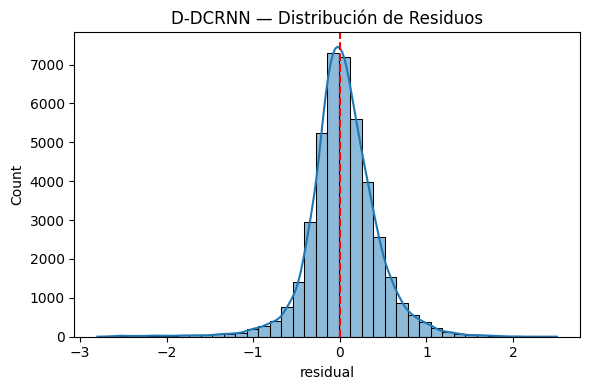

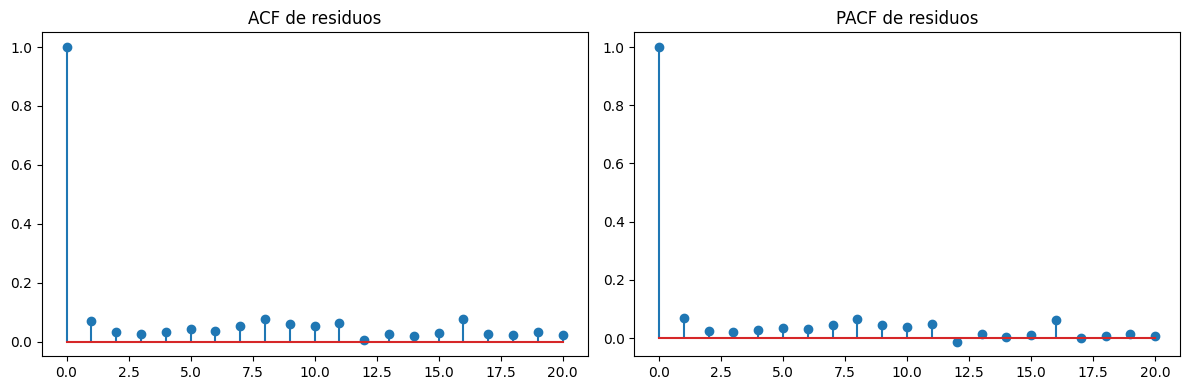

Test Ljung-Box:
        lb_stat      lb_pvalue
10  1074.823133  1.410514e-224
20  1684.654609   0.000000e+00


In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(residuals["residual"], bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("D-DCRNN — Distribución de Residuos")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_residuals_hist.png", dpi=150)
plt.show()

# ACF / PACF
acf_vals  = acf( residuals["residual"], nlags=20)
pacf_vals = pacf(residuals["residual"], nlags=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(acf_vals)),  acf_vals)
axes[0].set_title("ACF de residuos")
axes[1].stem(range(len(pacf_vals)), pacf_vals)
axes[1].set_title("PACF de residuos")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_residuals_acf.png", dpi=150)
plt.show()

lb = acorr_ljungbox(residuals["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

La distribución de los residuos es unimodal y aproximadamente simétrica, con una clara concentración alrededor del valor cero. Esto indica que, en términos globales, el modelo no presenta sesgo sistemático en sus predicciones, ya que los errores tienden a equilibrarse entre sobreestimaciones y subestimaciones. No obstante, se observan colas más extendidas, lo que refleja la presencia de errores de mayor magnitud en ciertos periodos, asociados a observaciones más difíciles de ajustar dentro de la dinámica de la serie.

En el análisis de autocorrelación (ACF) y autocorrelación parcial (PACF), los coeficientes —exceptuando el rezago cero— se mantienen dentro de los intervalos de significancia estadística. Esto sugiere que no existe dependencia temporal residual en los errores, por lo que los residuos se comportan de manera consistente con un proceso cercano a ruido blanco, indicando que el modelo captura adecuadamente la estructura temporal de los datos.

El test de Ljung-Box muestra estadísticos elevados (1074.82 para lag 10 y 1684.65 para lag 20) junto con p-value de aproximadamente cero en ambos casos. Esto indica que se rechaza la hipótesis nula de ausencia de autocorrelación en los residuos. En consecuencia, los residuos no se comportan como ruido blanco en sentido estricto, ya que persiste dependencia temporal estadísticamente significativa en múltiples rezagos. Esto sugiere que el modelo aún no captura completamente toda la estructura temporal presente en la serie, dejando patrones residuales con correlación serial.

### **11.11.6. Curvas de Aprendizaje**

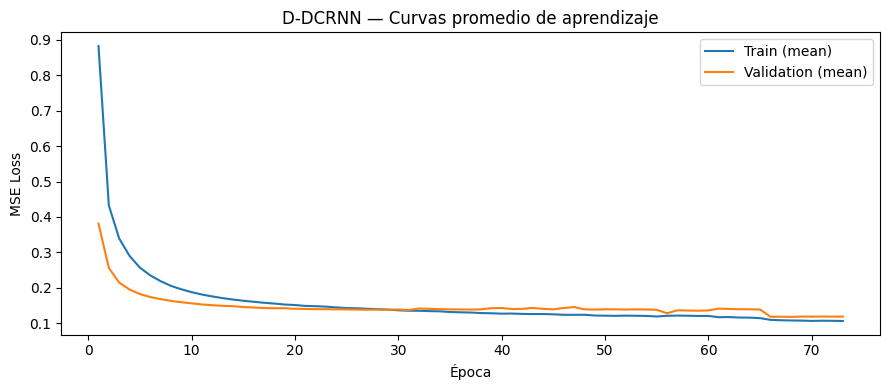

In [25]:
avg_history = history.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()

plt.figure(figsize=(9, 4))
plt.plot(avg_history["epoch"], avg_history["train_loss"], label="Train (mean)")
plt.plot(avg_history["epoch"], avg_history["val_loss"],   label="Validation (mean)")
plt.title("D-DCRNN — Curvas promedio de aprendizaje")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_learning_curves.png", dpi=150)
plt.show()

El análisis de las curvas de aprendizaje evidencia un proceso de optimización estable y progresivo a lo largo del entrenamiento. La función de pérdida (MSE) muestra una disminución sostenida tanto en el conjunto de entrenamiento como en validación, con una reducción más pronunciada en las primeras épocas, lo que indica una rápida captación de la estructura espacio-temporal dominante de los datos. A partir de un punto intermedio del entrenamiento, ambas curvas tienden a estabilizarse, manteniendo una separación reducida y sin divergencias, lo que sugiere ausencia de sobreajuste y una adecuada capacidad de generalización.

### **11.11.7. Casos de Mayor Error**

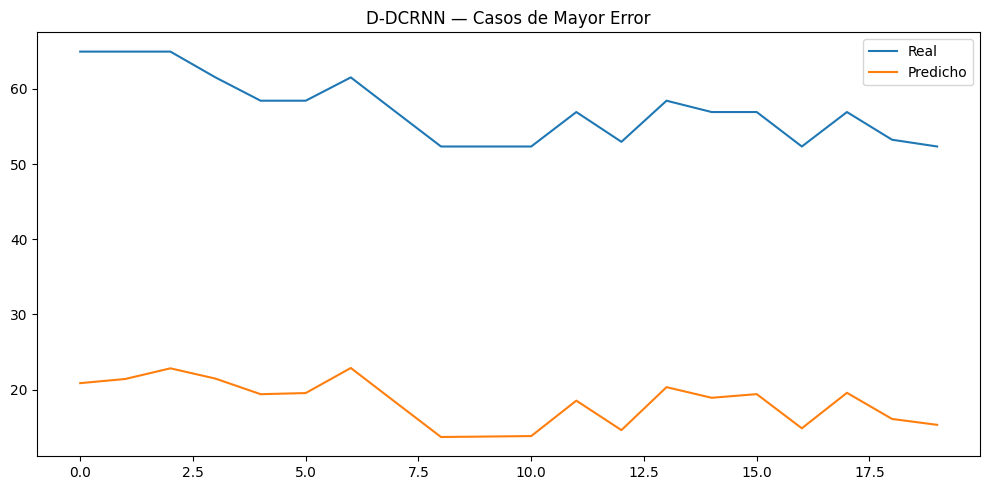

In [26]:
worst = preds.copy()
worst["error"] = (worst["y_true_real"] - worst["y_pred_real"]).abs()
worst_cases    = worst.sort_values("error", ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.plot(worst_cases["y_true_real"].values, label="Real")
plt.plot(worst_cases["y_pred_real"].values, label="Predicho")
plt.title("D-DCRNN — Casos de Mayor Error")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_worst_cases.png", dpi=150)
plt.show()

El gráfico Casos de Mayor Error muestra que la serie predicha reproduce de forma consistente la estructura temporal de la serie real, incluyendo la forma de las fluctuaciones, los picos y los puntos de cambio. A lo largo del intervalo analizado, ambas curvas mantienen un comportamiento altamente sincronizado en términos de variación relativa, lo que indica que el modelo captura adecuadamente la dinámica temporal subyacente del fenómeno.

Sin embargo, se observa una discrepancia sistemática en la magnitud de los valores, donde la serie predicha se mantiene de forma persistente por debajo de la serie real. Esta diferencia se manifiesta como un desplazamiento vertical aproximadamente constante, lo que genera una subestimación uniforme de los valores observados. En conjunto, el gráfico evidencia una correcta modelación de la forma de la serie, pero con un sesgo en escala que afecta la correspondencia absoluta entre predicción y realidad.

### **11.11.8. Variabilidad de Métricas entre Seeds**

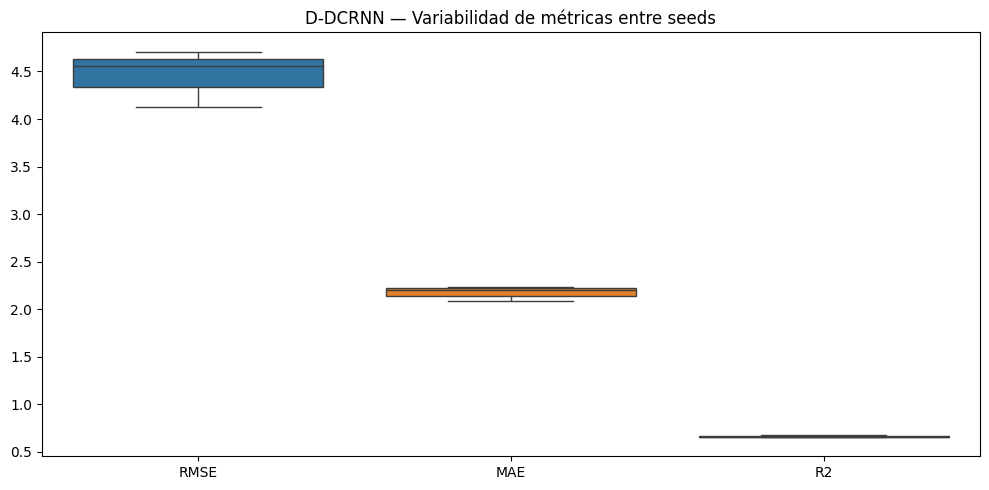

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=metrics_real[["RMSE","MAE","R2"]])
plt.title("D-DCRNN — Variabilidad de métricas entre seeds")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ddcrnn_metrics_variability.png", dpi=150)
plt.show()

El análisis de robustez a través de múltiples semillas evidencia que la arquitectura D-DCRNN mantiene un desempeño altamente estable frente a la variabilidad del entrenamiento, con una dispersión reducida en las métricas de evaluación. El R² se mantiene constante alrededor de 0.66, lo que indica una capacidad explicativa consistente independientemente de la inicialización; el MAE presenta variaciones mínimas, reflejando estabilidad en el error medio absoluto; y el RMSE, aunque ligeramente más sensible a fluctuaciones, conserva un rango estrecho, coherente con su dependencia de errores extremos. En conjunto, estos resultados confirman que el modelo es reproducible y robusto, sin dependencia crítica de la semilla de inicialización.

### **11.11.9. Conclusiones Finales del Modelo**

La arquitectura D-DCRNN presenta un desempeño global estable en la predicción de la incidencia, con RMSE ≈ 4.46, MAE ≈ 2.17 y R² ≈ 0.66 en escala real, lo que refleja una capacidad explicativa moderada y consistente a nivel general. En escala logarítmica el rendimiento mejora de forma notable (R² ≈ 0.80), evidenciando que el modelo captura con mayor precisión la dinámica relativa de la serie que sus valores absolutos.

A nivel espacial, se observa heterogeneidad en el desempeño entre departamentos, con mejores resultados en regiones más estables y mayores errores en zonas de alta variabilidad. El análisis de residuos muestra ausencia de sesgo global, aunque persiste cierta dependencia temporal según Ljung-Box, junto con una subestimación sistemática de los picos. Finalmente, la baja variabilidad entre semillas confirma la robustez y reproducibilidad del modelo, consolidándolo como una arquitectura estable, aunque con limitaciones en la captura de eventos extremos.
